<a href="https://colab.research.google.com/github/mkvarr/pima-diabetes-ml/blob/main/pima_diabetes_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
# Load the Pima Indians Diabetes dataset from a public URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Column names (the dataset file doesn't include them)
column_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigree",
    "Age",
    "Outcome"
]

# Read the data into a pandas DataFrame
df = pd.read_csv(url, names=column_names)

# Show the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# How big is the dataset?
print("Shape (rows, columns):", df.shape)
print()

# What types are the columns, and is any data missing?
df.info()

Shape (rows, columns): (768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Pregnancies       768 non-null    int64  
 1   Glucose           768 non-null    int64  
 2   BloodPressure     768 non-null    int64  
 3   SkinThickness     768 non-null    int64  
 4   Insulin           768 non-null    int64  
 5   BMI               768 non-null    float64
 6   DiabetesPedigree  768 non-null    float64
 7   Age               768 non-null    int64  
 8   Outcome           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Columns where a value of 0 is medically impossible
suspicious_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count how many zeros are in each of those columns
print("Number of zeros in each suspicious column:\n")
for col in suspicious_columns:
    zero_count = (df[col] == 0).sum()
    percent = (zero_count / len(df)) * 100
    print(f"{col:20} {zero_count:4} zeros  ({percent:.1f}% of data)")

Number of zeros in each suspicious column:

Glucose                 5 zeros  (0.7% of data)
BloodPressure          35 zeros  (4.6% of data)
SkinThickness         227 zeros  (29.6% of data)
Insulin               374 zeros  (48.7% of data)
BMI                    11 zeros  (1.4% of data)


In [5]:
# Replace 0 with NaN (Python's "missing value" marker) in the suspicious columns
df[suspicious_columns] = df[suspicious_columns].replace(0, np.nan)

# Now confirm how many "real" missing values we have
print("Missing values after marking zeros as missing:\n")
print(df[suspicious_columns].isnull().sum())

# Fill missing values with each column's median
for col in suspicious_columns:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"Filled {col} missing values with median = {median_value}")

print("\nMissing values after imputation:\n")
print(df[suspicious_columns].isnull().sum())

Missing values after marking zeros as missing:

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Filled Glucose missing values with median = 117.0
Filled BloodPressure missing values with median = 72.0
Filled SkinThickness missing values with median = 29.0
Filled Insulin missing values with median = 125.0
Filled BMI missing values with median = 32.3

Missing values after imputation:

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [6]:
# Separate the features (X) from the target (y)
X = df.drop("Outcome", axis=1)  # features = everything except Outcome
y = df["Outcome"]                # target = just the Outcome column

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # makes the split reproducible
    stratify=y           # keep diabetic/non-diabetic ratio balanced in both sets
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set:     {X_test.shape[0]} patients")
print()
print(f"Training set diabetic rate: {y_train.mean():.1%}")
print(f"Test set diabetic rate:     {y_test.mean():.1%}")

Training set: 614 patients
Test set:     154 patients

Training set diabetic rate: 34.9%
Test set diabetic rate:     35.1%


In [7]:
# Create the model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
logreg.fit(X_train, y_train)

# Use the trained model to predict on the test set
y_pred_logreg = logreg.predict(X_test)

# Check how accurate it was
accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy:.1%}")

Logistic Regression Accuracy: 70.1%


In [8]:
# Get probabilities (not just 0/1 predictions) for AUC calculation
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Calculate metrics
cm = confusion_matrix(y_test, y_pred_logreg)
auc = roc_auc_score(y_test, y_pred_proba_logreg)

# Show the confusion matrix clearly
print("Confusion Matrix:")
print(f"                     Predicted Not Diabetic  Predicted Diabetic")
print(f"Actual Not Diabetic        {cm[0][0]:3}                    {cm[0][1]:3}")
print(f"Actual Diabetic            {cm[1][0]:3}                    {cm[1][1]:3}")
print()
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.1%}")
print(f"AUC:      {auc:.3f}")
print()

# Break down the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly said 'not diabetic'): {tn}")
print(f"False Positives (wrongly said 'diabetic'):       {fp}")
print(f"False Negatives (MISSED diabetics):              {fn}  ← most dangerous in medicine")
print(f"True Positives  (correctly caught diabetics):    {tp}")

Confusion Matrix:
                     Predicted Not Diabetic  Predicted Diabetic
Actual Not Diabetic         81                     19
Actual Diabetic             27                     27

Accuracy: 70.1%
AUC:      0.813

True Negatives  (correctly said 'not diabetic'): 81
False Positives (wrongly said 'diabetic'):       19
False Negatives (MISSED diabetics):              27  ← most dangerous in medicine
True Positives  (correctly caught diabetics):    27


In [9]:
# Create the Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,   # number of trees in the forest
    random_state=42     # reproducibility
)

# Train it
rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Display results
print("=" * 55)
print("RANDOM FOREST RESULTS")
print("=" * 55)
print(f"Accuracy: {rf_accuracy:.1%}")
print(f"AUC:      {rf_auc:.3f}")
print()
print("Confusion Matrix:")
print(f"                     Predicted Not Diabetic  Predicted Diabetic")
print(f"Actual Not Diabetic        {rf_cm[0][0]:3}                    {rf_cm[0][1]:3}")
print(f"Actual Diabetic            {rf_cm[1][0]:3}                    {rf_cm[1][1]:3}")
print()
tn, fp, fn, tp = rf_cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives (MISSED diabetics): {fn}")
print(f"True Positives:  {tp}")

print()
print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(f"{'Metric':<15} {'Logistic Regression':<22} {'Random Forest':<15}")
print(f"{'Accuracy':<15} {'70.1%':<22} {rf_accuracy:.1%}")
print(f"{'AUC':<15} {'0.813':<22} {rf_auc:.3f}")

RANDOM FOREST RESULTS
Accuracy: 77.9%
AUC:      0.819

Confusion Matrix:
                     Predicted Not Diabetic  Predicted Diabetic
Actual Not Diabetic         88                     12
Actual Diabetic             22                     32

True Negatives:  88
False Positives: 12
False Negatives (MISSED diabetics): 22
True Positives:  32

MODEL COMPARISON
Metric          Logistic Regression    Random Forest  
Accuracy        70.1%                  77.9%
AUC             0.813                  0.819


Feature Importance (Random Forest):
Glucose              0.274  ███████████████████████████
BMI                  0.162  ████████████████
DiabetesPedigree     0.125  ████████████
Age                  0.113  ███████████
Insulin              0.091  █████████
BloodPressure        0.084  ████████
Pregnancies          0.081  ████████
SkinThickness        0.070  ███████


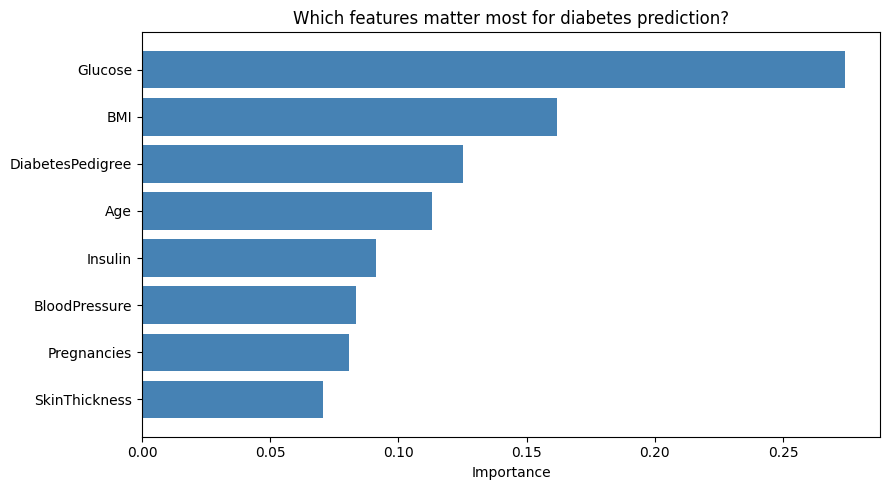

In [10]:
# Get feature importances from the Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print("=" * 40)
for _, row in feature_importance.iterrows():
    bar = "█" * int(row['Importance'] * 100)
    print(f"{row['Feature']:<20} {row['Importance']:.3f}  {bar}")

# Also plot it
plt.figure(figsize=(9, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Which features matter most for diabetes prediction?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()